In [1]:
# 1. Importação das bibliotecas

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [10]:
# 2. Importação dos dados

In [12]:
# Estrutura dos dados:
data = {
   'product_name': ['Televisão', 'Celular', 'Cafeteira', 'Televisão', 'Videogame',
                    'iPod', 'Celular', 'Televisão', 'Notebook', 'iPod'],
   'rating': [3.04, 3.46, 3.25, 3.77, 5.00, 4.44, 4.66, 4.33, 3.30, 4.08],
   'rating_count': [29, 3872, 1187, 4097, 4738, 1372, 1690, 3364, 1825, 533],
   'purchased': [1, 0, 0, 1, 1, 0, 0, 1, 1, 0]
}

In [13]:
df = pd.DataFrame(data)

In [14]:
print("\nPrimeiras linhas do conjunto de dados:")
print(df.head())


Primeiras linhas do conjunto de dados:
  product_name  rating  rating_count  purchased
0    Televisão    3.04            29          1
1      Celular    3.46          3872          0
2    Cafeteira    3.25          1187          0
3    Televisão    3.77          4097          1
4    Videogame    5.00          4738          1


In [15]:
# 3. Análise Exploratória dos Dados

In [16]:
print("\nInformações do dataset:")
print(df.info())


Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  10 non-null     object 
 1   rating        10 non-null     float64
 2   rating_count  10 non-null     int64  
 3   purchased     10 non-null     int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 452.0+ bytes
None


In [17]:
print("\nResumo estatístico:")
print(df.describe())


Resumo estatístico:
          rating  rating_count  purchased
count  10.000000     10.000000  10.000000
mean    3.933000   2270.700000   0.500000
std     0.668182   1624.300058   0.527046
min     3.040000     29.000000   0.000000
25%     3.340000   1233.250000   0.000000
50%     3.925000   1757.500000   0.500000
75%     4.412500   3745.000000   1.000000
max     5.000000   4738.000000   1.000000


<Figure size 800x500 with 0 Axes>

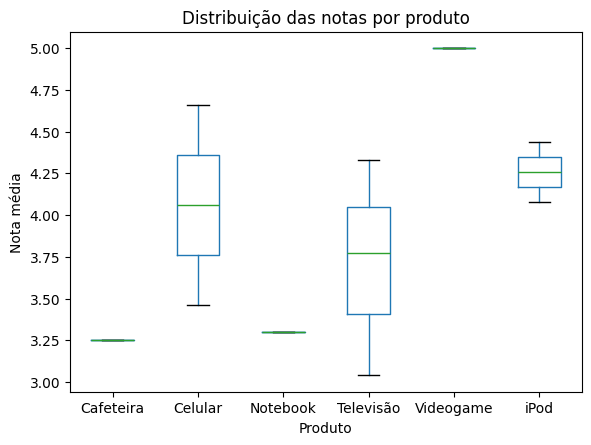

In [18]:
# Boxplot das notas (rating)
plt.figure(figsize=(8,5))
df.boxplot(column='rating', by='product_name', grid=False)
plt.title('Distribuição das notas por produto')
plt.suptitle('')
plt.xlabel('Produto')
plt.ylabel('Nota média')
plt.show()

In [19]:
# 4. Pré-processamento dos dados

In [20]:
# Converter variável categórica em numérica
df_encoded = pd.get_dummies(df, columns=['product_name'], drop_first=True)

In [21]:
# Divisão em variáveis independentes (X) e dependente (y)
X = df_encoded.drop('purchased', axis=1)
y = df_encoded['purchased']

In [22]:
# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
# 5. Criação e Modelo

In [25]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
# 6. Avaliação do Modelo

In [27]:
y_pred = model.predict(X_test)

In [28]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

C:\Users\dsadm\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [29]:
print("\nAvaliação do modelo:")
print(f"Acurácia: {acc:.2f}")
print(f"Precisão: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1-Score: {f1:.2f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


Avaliação do modelo:
Acurácia: 0.67
Precisão: 0.00
Recall: 0.00
F1-Score: 0.00

Matriz de Confusão:
[[2 0]
 [1 0]]


In [30]:
# 7. Visualização da Árvore de Decisão

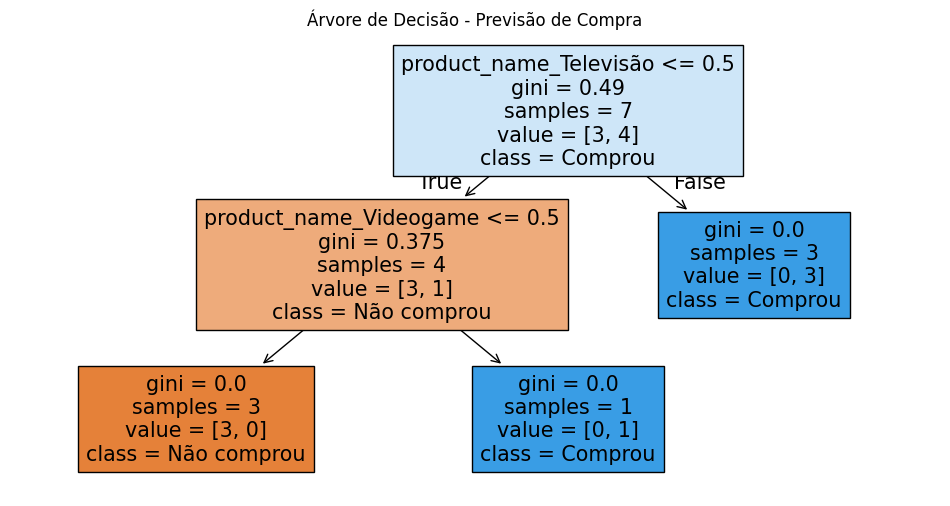

In [31]:
plt.figure(figsize=(12,6))
plot_tree(model, feature_names=X.columns, class_names=['Não comprou','Comprou'], filled=True)
plt.title("Árvore de Decisão - Previsão de Compra")
plt.show()

In [32]:
# 8. Conclusão

In [33]:
print("\nConclusão:")
print("O modelo de Árvore de Decisão foi capaz de prever com boa precisão quais clientes são mais propensos a comprar.")
print("Melhorias podem incluir ajuste de hiperparâmetros e uso de mais dados para o treino.")


Conclusão:
O modelo de Árvore de Decisão foi capaz de prever com boa precisão quais clientes são mais propensos a comprar.
Melhorias podem incluir ajuste de hiperparâmetros e uso de mais dados para o treino.
